In [42]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("Entorno de Machine Learning preparado")

Entorno de Machine Learning preparado


In [43]:
data = pd.read_csv("../data/manufacturing_data.csv")

data.head()

,temperature_C,pressure_bar,cycle_time_min,machine_speed_rpm,vibration_mm,humidity_percent,defect
0,77.483571,3.660753,36.741431,90.291420,0.040563,45.491031,0
1,74.308678,3.847250,36.416618,104.175215,0.070254,44.679459,0
2,78.238443,3.701309,30.317401,111.194574,0.046036,49.758954,0
3,82.615149,4.055209,37.897921,122.245034,0.051811,52.664156,0
4,73.829233,4.598589,27.549587,135.362435,0.064348,48.434235,1


In [44]:
X = data.drop("defect", axis=1)

y = data["defect"]

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (8000, 6)
Datos de prueba: (2000, 6)


In [46]:
model = RandomForestClassifier(
    n_estimators=200,
    class_weight={0:1, 1:5},
    random_state=42
)

model.fit(
    X_train,
    y_train
)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


In [47]:
y_pred = model.predict(X_test)

print(y_pred[:20])

[0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0]


In [48]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.823


In [49]:
print("Defectos reales en test:")
print(y_test.value_counts())

print("\nPredicciones del modelo:")
print(pd.Series(y_pred).value_counts())

Defectos reales en test:
defect
0    1710
1     290
Name: count, dtype: int64

Predicciones del modelo:
0    1678
1     322
Name: count, dtype: int64


In [50]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.89      0.90      1710
           1       0.40      0.44      0.42       290

    accuracy                           0.82      2000
   macro avg       0.65      0.67      0.66      2000
weighted avg       0.83      0.82      0.83      2000



In [51]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm

array([[1517,  193],
       [ 161,  129]])

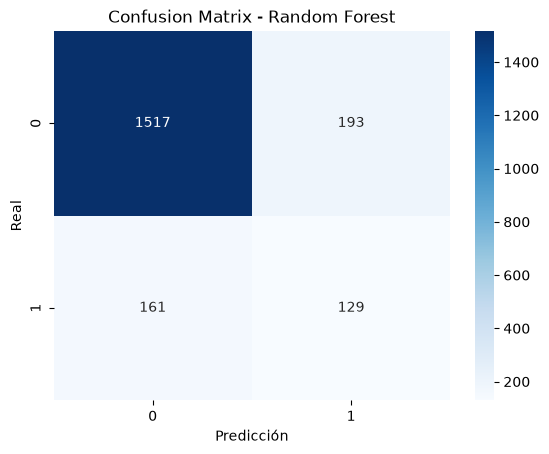

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Confusion Matrix - Random Forest")

plt.savefig(
    "../results/confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()


In [53]:
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

importance = importance.sort_values(
    by="importance",
    ascending=False
)

importance

,feature,importance
2,cycle_time_min,0.246473
0,temperature_C,0.189837
4,vibration_mm,0.185707
1,pressure_bar,0.135133
5,humidity_percent,0.121429
3,machine_speed_rpm,0.121421


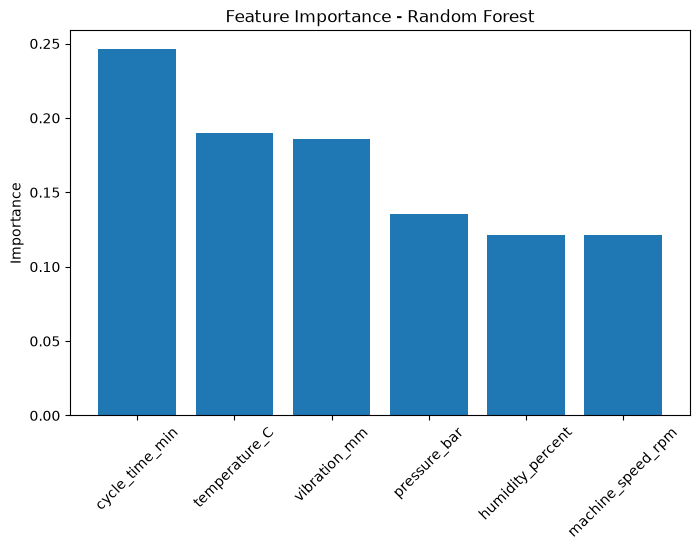

In [67]:
plt.figure(figsize=(8,5))

plt.bar(
    importance["feature"],
    importance["importance"]
)

plt.xticks(rotation=45)

plt.title("Feature Importance - Random Forest")
plt.ylabel("Importance")

plt.savefig(
    "../results/feature_importance.png",
    bbox_inches="tight"
)

plt.show()

In [57]:
import joblib

joblib.dump(
    model,
    "../models/random_forest_quality_model.pkl"
)

print("Modelo guardado correctamente")

Modelo guardado correctamente


In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import accuracy_score, recall_score, f1_score

In [59]:
models = {

    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight={0:1, 1:5},
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        random_state=42
    )
}

print("Modelos preparados")

Modelos preparados


In [68]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    results.append({

        "Model": name,
        "Accuracy": accuracy_score(y_test, prediction),
        "Recall_defect": recall_score(y_test, prediction),
        "F1_defect": f1_score(y_test, prediction)

    })

results_df = pd.DataFrame(results)

results_df.to_csv(
    "../results/model_comparison.csv",
    index=False
)

results_df

,Model,Accuracy,Recall_defect,F1_defect
0,Logistic Regression,0.6230,0.634483,0.327986
1,Random Forest,0.8225,0.451724,0.424635
2,Gradient Boosting,0.8570,0.103448,0.173410


In [61]:
# Obtener probabilidades de defecto

y_prob = model.predict_proba(X_test)[:,1]

y_prob[:10]

array([0.05872353, 0.05607211, 0.05226679, 0.05314611, 0.05226679,
       0.05314611, 0.39048322, 0.38352278, 0.08022474, 0.0486906 ])

In [62]:
threshold = 0.30

y_pred_threshold = (y_prob >= threshold).astype(int)

In [63]:
print(classification_report(y_test, y_pred_threshold))

              precision    recall  f1-score   support

           0       0.91      0.84      0.87      1710
           1       0.36      0.54      0.43       290

    accuracy                           0.79      2000
   macro avg       0.64      0.69      0.65      2000
weighted avg       0.83      0.79      0.81      2000



In [ ]:
import joblib

joblib.dump(
    model,
    "../models/random_forest_final_model.pkl"
)

print("Modelo final guardado")

Modelo final guardado


In [65]:
model_package = {
    "model": model,
    "threshold": 0.30
}

joblib.dump(
    model_package,
    "../models/medical_device_quality_AI.pkl"
)

print("Modelo y umbral guardados")

Modelo y umbral guardados
